In [64]:
install.packages("foreign")
install.packages("dplyr")

library(foreign)
library(dplyr)

# Ler cada um dos arquivos em upload
base_2022 <- read.dbf("SIFCBR22.dbf", as.is = TRUE)
base_2023 <- read.dbf("SIFCBR23.dbf", as.is = TRUE)
base_2024 <- read.dbf("SIFCBR24.dbf", as.is = TRUE)

# Padronizar nomes das colunas das bases
names(base_2022) <- toupper(names(base_2022))
names(base_2023) <- toupper(names(base_2023))
names(base_2024) <- toupper(names(base_2024))

# Unir tudo em uma base só
dados <- bind_rows(base_2022, base_2023, base_2024)

# Tratar com base no dicionário do SINAN

library(dplyr)

dados <- dados %>%
  mutate(

    NU_ANO = as.factor(NU_ANO),

    ANT_IDADE = as.numeric(ANT_IDADE),

    ANT_RACA = case_when(
      ANT_RACA == 1 ~ "Branca",
      ANT_RACA == 2 ~ "Preta",
      ANT_RACA == 3 ~ "Amarela",
      ANT_RACA == 4 ~ "Parda",
      ANT_RACA == 5 ~ "Indígena",
      TRUE ~ "Ignorado"
    ),

    ESCOLMAE = as.character(ESCOLMAE),

    ESCOLMAE = case_when(
      ESCOLMAE %in% c("0") ~ "Analfabeto",
      ESCOLMAE %in% c("1", "01") ~ "1ª a 4ª série incompleta do EF",
      ESCOLMAE %in% c("2", "02") ~ "até 4ª série completa do EF",
      ESCOLMAE %in% c("3", "03") ~ "5ª a 8ª série incompleta do EF",
      ESCOLMAE %in% c("4", "04") ~ "Ensino fundamental completo",
      ESCOLMAE %in% c("5", "05") ~ "Ensino médio incompleto",
      ESCOLMAE %in% c("6", "06") ~ "Ensino médio completo",
      ESCOLMAE %in% c("7", "07") ~ "Educação superior incompleta",
      ESCOLMAE %in% c("8", "08") ~ "Educação superior completa",
      ESCOLMAE %in% c("10") ~ "Não se aplica",
      TRUE ~ "Ignorado"
    ),

    ANT_PRE_NA = case_when(
      ANT_PRE_NA == 1 ~ "Sim",
      ANT_PRE_NA == 2 ~ "Não",
      TRUE ~ "Ignorado"
    ),

    ANTSIFIL_N = case_when(
      ANTSIFIL_N == 1 ~ "Durante o pré-natal",
      ANTSIFIL_N == 2 ~ "No momento do parto/curetagem",
      ANTSIFIL_N == 3 ~ "Após o parto",
      ANTSIFIL_N == 4 ~ "Não realizado",
      TRUE ~ "Ignorado"
    ),

    ANT_TRATAD = case_when(
      ANT_TRATAD == 1 ~ "Sim",
      ANT_TRATAD == 2 ~ "Não",
      TRUE ~ "Ignorado"
    ),

    TRA_ESQUEM = case_when(
      TRA_ESQUEM == 1 ~ "Adequado",
      TRA_ESQUEM == 2 ~ "Inadequado",
      TRA_ESQUEM == 3 ~ "Não realizado",
      TRUE ~ "Ignorado"
    ),

    EVOLUCAO = case_when(
      EVOLUCAO == 1 ~ "Vivo",
      EVOLUCAO == 2 ~ "Óbito por sífilis congênita",
      EVOLUCAO == 3 ~ "Óbito por outras causas",
      EVOLUCAO == 4 ~ "Aborto",
      EVOLUCAO == 5 ~ "Natimorto",
      EVOLUCAO == 9 ~ "Ignorado",
      TRUE ~ "Ignorado"
    )
  )

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [40]:
summary(dados)
str(dados)

    TP_NOT            SEM_NOT           ID_AGRAVO           DT_NOTIFIC        
 Length:64584       Length:64584       Length:64584       Min.   :2022-01-01  
 Class :character   Class :character   Class :character   1st Qu.:2022-08-06  
 Mode  :character   Mode  :character   Mode  :character   Median :2023-03-17  
                                                          Mean   :2023-03-24  
                                                          3rd Qu.:2023-11-07  
                                                          Max.   :2024-08-07  
                                                                              
  NU_ANO       SG_UF_NOT          ID_MUNICIP         ID_REGIONA       
 2022:26512   Length:64584       Length:64584       Length:64584      
 2023:25310   Class :character   Class :character   Class :character  
 2024:12762   Mode  :character   Mode  :character   Mode  :character  
                                                                      
             

'data.frame':	64584 obs. of  64 variables:
 $ TP_NOT    : chr  "2" "2" "2" "2" ...
 $ SEM_NOT   : chr  "202206" "202244" "202244" "202203" ...
 $ ID_AGRAVO : chr  "A509" "A509" "A509" "A509" ...
 $ DT_NOTIFIC: Date, format: "2022-02-07" "2022-11-04" ...
 $ NU_ANO    : Factor w/ 3 levels "2022","2023",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ SG_UF_NOT : chr  "26" "33" "33" "33" ...
 $ ID_MUNICIP: chr  "261160" "330100" "330100" "330227" ...
 $ ID_REGIONA: chr  "1497" NA NA NA ...
 $ DT_DIAG   : Date, format: "2017-02-18" "2018-01-22" ...
 $ SEM_DIAG  : chr  NA NA NA NA ...
 $ NU_IDADE_N: int  2000 2008 2000 2000 3002 2009 2027 3002 3003 2009 ...
 $ CS_SEXO   : chr  "M" "F" "F" "M" ...
 $ CS_GESTANT: chr  "6" "6" "6" "6" ...
 $ CS_RACA   : chr  "9" "4" "4" "1" ...
 $ CS_ESCOL_N: chr  "10" "10" "10" "10" ...
 $ SG_UF     : chr  "26" "33" "33" "33" ...
 $ ID_MN_RESI: chr  "261160" "330100" "330100" "330227" ...
 $ ID_RG_RESI: chr  "1497" NA NA NA ...
 $ ID_PAIS   : chr  "1" "1" "1" "1" ...
 $ ANT_ID

Foi realizada a leitura e unificação dos bancos de dados de sífilis congênita referentes aos anos de 2022, 2023 e 2024, provenientes do DATASUS (formato DBF).
Em seguida, uma análise exploratória inicial por meio da função summary() e str(), permitindo identificar a estrutura das variáveis, tipos de dados e possíveis inconsistências.

In [41]:
names(dados)

[1] "TP_NOT"     "SEM_NOT"    "ID_AGRAVO"  "DT_NOTIFIC" "NU_ANO"    
 [6] "SG_UF_NOT"  "ID_MUNICIP" "ID_REGIONA" "DT_DIAG"    "SEM_DIAG"  
[11] "NU_IDADE_N" "CS_SEXO"    "CS_GESTANT" "CS_RACA"    "CS_ESCOL_N"
[16] "SG_UF"      "ID_MN_RESI" "ID_RG_RESI" "ID_PAIS"    "ANT_IDADE" 
[21] "ANT_RACA"   "ID_OCUPA_N" "ESCOLMAE"   "ANT_PRE_NA" "UF_PRE_NAT"
[26] "MUN_PRE_NA" "ANTSIFIL_N" "LAB_PARTO"  "LAB_TITU_2" "LAB_DT3"   
[31] "LAB_CONF"   "TRA_ESQUEM" "TRA_DT"     "ANT_TRATAD" "ANT_UF_CRI"
[36] "ANT_MUNI_C" "LABC_SANGU" "LABC_TIT_1" "LABC_DT_1"  "LABC_IGG"  
[41] "LABC_DT"    "LABC_LIQUO" "LABC_TIT_2" "LABC_DT_2"  "LABC_TITUL"
[46] "LABC_EVIDE" "LABC_LIQ_1" "TRA_DIAG_T" "TRA_ESQU_1" "DS_ESQUEMA"
[51] "EVOLUCAO"   "DT_OBITO"   "EVO_DIAG_N" "TRA_DIAG_C" "CLI_ICTERI"
[56] "CLI_RINITE" "CLI_ANEMIA" "CLI_ESPLEN" "HEPATO"     "CLI_OSTEO" 
[61] "LESOES"     "CLI_OUTRO"  "SIN_OUTR_E" "CLI_PSEUDO"

In [42]:
variaveis_boletim <- dados %>%
  select(
    NU_ANO,
    DT_DIAG,
    ID_MN_RESI,
    ANT_IDADE,
    ANT_RACA,
    ESCOLMAE,
    ANT_PRE_NA,
    ANTSIFIL_N,
    TRA_ESQUEM,
    ANT_TRATAD,
    EVOLUCAO,
    EVO_DIAG_N,
    TRA_DIAG_C
  )

In [43]:
summary(variaveis_boletim)

  NU_ANO         DT_DIAG            ID_MN_RESI          ANT_IDADE     
 2022:26512   Min.   :2012-11-12   Length:64584       Min.   :  0.00  
 2023:25310   1st Qu.:2022-07-22   Class :character   1st Qu.: 20.00  
 2024:12762   Median :2023-03-06   Mode  :character   Median : 24.00  
              Mean   :2023-03-10                      Mean   : 24.84  
              3rd Qu.:2023-10-28                      3rd Qu.: 28.00  
              Max.   :2024-06-30                      Max.   :999.00  
                                                      NA's   :1489    
   ANT_RACA           ESCOLMAE          ANT_PRE_NA         ANTSIFIL_N       
 Length:64584       Length:64584       Length:64584       Length:64584      
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                               

In [44]:
table(variaveis_boletim$ANT_PRE_NA)
round(prop.table(table(variaveis_boletim$ANT_PRE_NA)) * 100, 1)


Ignorado      Não      Sim 
    2985     8252    53347 


Ignorado      Não      Sim 
     4.6     12.8     82.6 

Observou-se que 82,6% das gestantes realizaram pré-natal, enquanto 12,8% não realizaram acompanhamento. Destaca-se ainda que 4,6% dos registros apresentaram informação ignorada, evidenciando possíveis falhas no preenchimento dos dados.

In [45]:
table(variaveis_boletim$TRA_ESQUEM)
round(prop.table(table(variaveis_boletim$TRA_ESQUEM)) * 100, 1)


     Adequado      Ignorado    Inadequado Não realizado 
         3503          7566         33029         20486 


     Adequado      Ignorado    Inadequado Não realizado 
          5.4          11.7          51.1          31.7 

Em relação ao tratamento materno, observou-se que apenas 5,4% das gestantes receberam tratamento adequado. A maioria dos casos apresentou tratamento inadequado (51,1%) ou não realizou tratamento (31,7%). Além disso, 11,7% dos registros estavam com informação ignorada.

In [46]:
table(variaveis_boletim$ANTSIFIL_N)
round(prop.table(table(variaveis_boletim$ANTSIFIL_N)) * 100, 1)


                 Após o parto           Durante o pré-natal 
                         3840                         38481 
                     Ignorado                 Não realizado 
                         2328                           511 
No momento do parto/curetagem 
                        19424 


                 Após o parto           Durante o pré-natal 
                          5.9                          59.6 
                     Ignorado                 Não realizado 
                          3.6                           0.8 
No momento do parto/curetagem 
                         30.1 

Quanto ao momento do diagnóstico da sífilis materna, 59,6% dos casos foram identificados durante o pré-natal. Entretanto, 30,1% dos diagnósticos ocorreram apenas no momento do parto ou curetagem, e 5,9% no pós-parto, indicando perda de oportunidade de intervenção precoce. Observou-se ainda 3,6% de registros com informação ignorada.

In [47]:
table(variaveis_boletim$ANT_TRATAD)
round(prop.table(table(variaveis_boletim$ANT_TRATAD)) * 100, 1)


Ignorado      Não      Sim 
   20469    31607    12508 


Ignorado      Não      Sim 
    31.7     48.9     19.4 

Em relação ao tratamento do parceiro, apenas 19,4% foram tratados, enquanto 48,9% não receberam tratamento. Destaca-se ainda elevada proporção de registros ignorados (31,7%), o que limita a avaliação adequada dessa variável.

In [48]:
variaveis_boletim$FAIXA_ETARIA <- cut(
  variaveis_boletim$ANT_IDADE,
  breaks = c(0, 19, 29, 39, 49, 100),
  labels = c("<20", "20-29", "30-39", "40-49", "50+"),
  right = TRUE
)

table(variaveis_boletim$FAIXA_ETARIA)
round(prop.table(table(variaveis_boletim$FAIXA_ETARIA)) * 100, 1)


  <20 20-29 30-39 40-49   50+ 
11979 37988 11732  1372     6 


  <20 20-29 30-39 40-49   50+ 
 19.0  60.2  18.6   2.2   0.0 

Observou-se predomínio de casos na faixa etária de 20 a 29 anos (60,2%), seguida pelas faixas menores de 20 anos (19,0%) e de 30 a 39 anos (18,6%). As faixas etárias acima de 40 anos representaram pequena proporção dos casos.

In [49]:
table(variaveis_boletim$ANT_RACA)
round(prop.table(table(variaveis_boletim$ANT_RACA)) * 100, 1)


 Amarela   Branca Ignorado Indígena    Parda    Preta 
     234    15519     4424      183    38578     5646 


 Amarela   Branca Ignorado Indígena    Parda    Preta 
     0.4     24.0      6.8      0.3     59.7      8.7 

Quanto à raça/cor, observou-se predomínio de casos entre gestantes pardas (59,7%), seguidas por brancas (24,0%) e pretas (8,7%). As demais categorias apresentaram baixa frequência. Destaca-se ainda 6,8% de registros com informação ignorada.

In [66]:
table(dados$ESCOLMAE)
round(prop.table(table(dados$ESCOLMAE)) * 100, 1)


1ª a 4ª série incompleta do EF 5ª a 8ª série incompleta do EF 
                          1735                          10305 
   até 4ª série completa do EF     Educação superior completa 
                          1349                            918 
  Educação superior incompleta    Ensino fundamental completo 
                           854                           5500 
         Ensino médio completo        Ensino médio incompleto 
                         15260                           9025 
                      Ignorado                  Não se aplica 
                         19188                            450 


1ª a 4ª série incompleta do EF 5ª a 8ª série incompleta do EF 
                           2.7                           16.0 
   até 4ª série completa do EF     Educação superior completa 
                           2.1                            1.4 
  Educação superior incompleta    Ensino fundamental completo 
                           1.3                            8.5 
         Ensino médio completo        Ensino médio incompleto 
                          23.6                           14.0 
                      Ignorado                  Não se aplica 
                          29.7                            0.7 

Observou-se elevada proporção de registros com escolaridade ignorada (29,2%), indicando fragilidade no preenchimento dessa variável no sistema de informação. Entre os casos com informação válida, verificou-se predominância de mães com escolaridade de nível médio completo (23,6%), seguida por ensino fundamental incompleto (16,0%) e ensino médio incompleto (14,0%). As demais categorias apresentaram menor frequência, incluindo ensino fundamental completo (8,5%), níveis iniciais de escolaridade (até 4ª série incompleta e completa, totalizando cerca de 5,3%) e ensino superior (incompleto e completo, somando aproximadamente 2,7%).

Esse perfil sugere concentração dos casos em grupos com escolaridade intermediária, porém a elevada incompletude da variável limita uma análise mais robusta das desigualdades sociais associadas à ocorrência da sífilis congênita.

In [67]:
table(dados$EVOLUCAO)
prop.table(table(dados$EVOLUCAO)) * 100


                     Aborto                    Ignorado 
                       2839                        2180 
                  Natimorto     Óbito por outras causas 
                       1843                         497 
Óbito por sífilis congênita                        Vivo 
                        811                       56414 


                     Aborto                    Ignorado 
                  4.3958256                   3.3754490 
                  Natimorto     Óbito por outras causas 
                  2.8536480                   0.7695404 
Óbito por sífilis congênita                        Vivo 
                  1.2557290                  87.3498080 

Observou-se predominância de nascidos vivos entre os casos de sífilis congênita (87,3%). Entretanto, foram identificados desfechos adversos relevantes, incluindo abortos (4,4%) e natimortos (2,9%), que, em conjunto, representam uma parcela significativa dos casos e refletem eventos potencialmente evitáveis. A proporção de óbitos atribuídos diretamente à sífilis congênita foi de 1,3%, indicando a persistência de falhas na detecção e tratamento oportuno da infecção durante o pré-natal. A incompletude da variável foi relativamente baixa (3,4%), sugerindo boa qualidade do preenchimento para esse campo.

In [68]:
table(dados$TRA_DIAG_C)
prop.table(table(dados$TRA_DIAG_C)) * 100

< table of extent 0 >

numeric(0)

In [69]:
summary(dados$TRA_DIAG_C)

   Length     Class      Mode 
    64584 character character 

In [70]:
table(dados$TRA_DIAG_C, useNA = "ifany")


 <NA> 
64584 

A variável referente ao diagnóstico clínico da criança (TRA_DIAG_C) foi excluída da análise devido à ausência de dados válidos no banco, impossibilitando sua utilização para fins descritivos.

In [72]:
table(dados$NU_ANO)
round(prop.table(table(dados$NU_ANO)) * 100, 1)


 2022  2023  2024 
26512 25310 12762 


2022 2023 2024 
41.1 39.2 19.8 

Observa-se maior concentração de casos no ano de 2022 (41,1%), seguido de 2023 (39,2%) e 2024 (19,8%). A redução observada em 2024 pode estar relacionada à incompletude dos dados no período de consolidação das notificações no sistema de informação.

In [80]:
tab_ano <- dados %>%
  count(NU_ANO) %>%
  mutate(prop = round(n / sum(n) * 100, 1))
print(tab_ano)

  NU_ANO     n prop
1   2022 26512 41.1
2   2023 25310 39.2
3   2024 12762 19.8


In [81]:
tab_raca <- dados %>%
  count(ANT_RACA) %>%
  mutate(prop = round(n / sum(n) * 100, 1))
print(tab_raca)

  ANT_RACA     n prop
1  Amarela   234  0.4
2   Branca 15519 24.0
3 Ignorado  4424  6.8
4 Indígena   183  0.3
5    Parda 38578 59.7
6    Preta  5646  8.7


In [82]:
tab_escolaridade <- dados %>%
  count(ESCOLMAE) %>%
  mutate(prop = round(n / sum(n) * 100, 1))
print(tab_escolaridade)

                         ESCOLMAE     n prop
1  1ª a 4ª série incompleta do EF  1735  2.7
2  5ª a 8ª série incompleta do EF 10305 16.0
3      Educação superior completa   918  1.4
4    Educação superior incompleta   854  1.3
5     Ensino fundamental completo  5500  8.5
6           Ensino médio completo 15260 23.6
7         Ensino médio incompleto  9025 14.0
8                        Ignorado 19188 29.7
9                   Não se aplica   450  0.7
10    até 4ª série completa do EF  1349  2.1


In [24]:

tab_tratamento <- dados %>%
  mutate(Tratamento = case_when(
    TRA_ESQUEM == "Adequado" ~ "Adequado",
    TRA_ESQUEM == "Inadequado" ~ "Inadequado",
    TRA_ESQUEM == "Não realizado" ~ "Não realizado",
    TRUE ~ "Ignorado/Branco"
  )) %>%
  count(Tratamento) %>%
  mutate(prop = round(n/sum(n)*100, 1))


tab_desfecho <- dados %>%
  mutate(Desfecho = case_when(
    EVOLUCAO == "Vivo" ~ "Nascido Vivo",
    EVOLUCAO == "Aborto" ~ "Aborto",
    EVOLUCAO == "Natimorto" ~ "Natimorto",
    EVOLUCAO == "Óbito por sífilis congênita" ~ "Óbito por SC",
    EVOLUCAO == "Óbito por outras causas" ~ "Óbito por outras causas",
    TRUE ~ "Ignorado"
  )) %>%
  count(Desfecho) %>%
  mutate(prop = round(n/sum(n)*100, 1))


print(tab_tratamento)
print(tab_desfecho)

       Tratamento     n prop
1        Adequado  3503  5.4
2 Ignorado/Branco  7566 11.7
3      Inadequado 33029 51.1
4   Não realizado 20486 31.7
                 Desfecho     n prop
1                  Aborto  2839  4.4
2                Ignorado  2180  3.4
3            Nascido Vivo 56414 87.3
4               Natimorto  1843  2.9
5            Óbito por SC   811  1.3
6 Óbito por outras causas   497  0.8


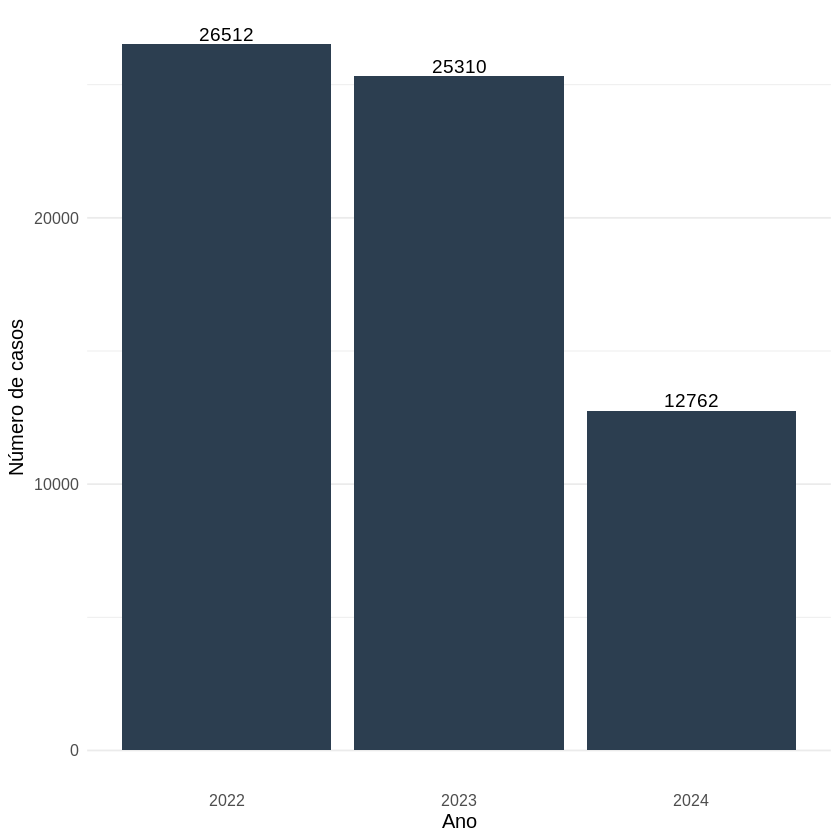

In [83]:
library(ggplot2)

ggplot(tab_ano, aes(x = NU_ANO, y = n)) +
  geom_col(fill = "#2C3E50") +
  geom_text(aes(label = n), vjust = -0.3, size = 4) +
  theme_minimal() +
  labs(x = "Ano", y = "Número de casos") +
  theme(
    text = element_text(size = 12),
    panel.grid.major.x = element_blank()
  )

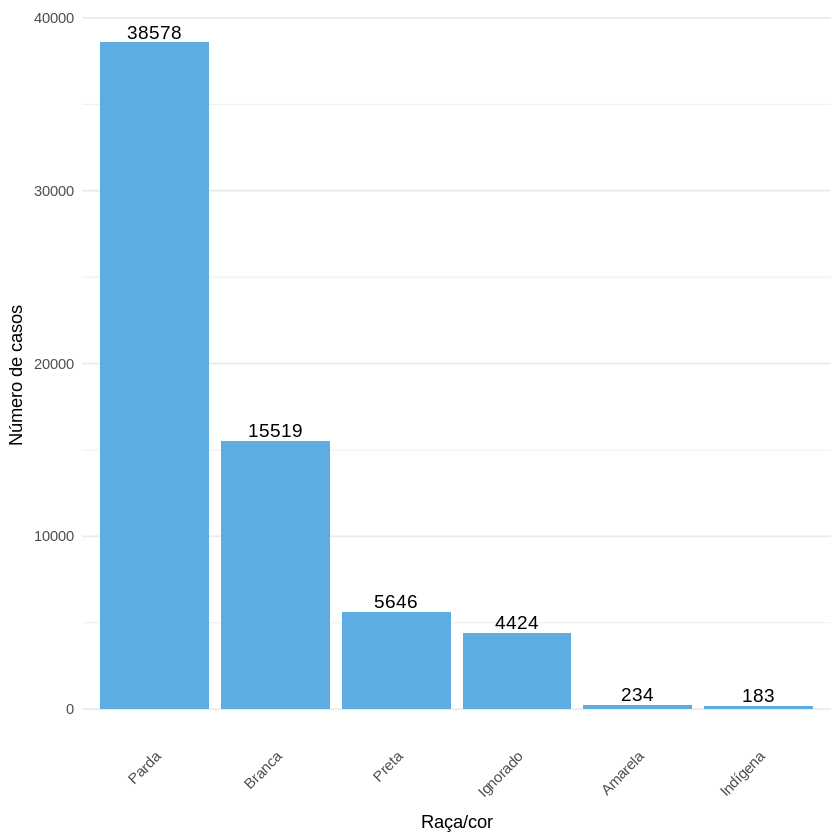

In [84]:
ggplot(tab_raca, aes(x = reorder(ANT_RACA, -n), y = n)) +
  geom_col(fill = "#5DADE2") +
  geom_text(aes(label = n), vjust = -0.3, size = 4) +
  theme_minimal() +
  labs(x = "Raça/cor", y = "Número de casos") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.x = element_blank()
  )

In [26]:
grafico_raca <- ggplot(tab_raca, aes(x = reorder(ANT_RACA, -n), y = n)) +
  geom_col(fill = "#5DADE2") +
  geom_text(aes(label = n), vjust = -0.3, size = 4) +
  theme_minimal() +
  labs(x = "Raça/cor", y = "Número de casos") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.x = element_blank()
  )

grafico_ano <- ggplot(tab_ano, aes(x = NU_ANO, y = n)) +
  geom_col(fill = "#2C3E50") +
  geom_text(aes(label = n), vjust = -0.3, size = 4) +
  theme_minimal() +
  labs(x = "Ano", y = "Número de casos") +
  theme(
    text = element_text(size = 12),
    panel.grid.major.x = element_blank()
  )

In [6]:
system("apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic")
install.packages("pander")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [14]:

linhas <- c(
  "---",
  "title: 'Boletim Epidemiológico: Sífilis Congênita'",
  "author: 'Livia Cunha'",
  "output: html_document",
  "---",
  "",
  "## 1. Introdução",
  "Relatório de análise dos dados de Sífilis Congênita (2022-2024).",
  "",
  "```{r setup, include=FALSE}",
  "library(dplyr)",
  "library(ggplot2)",
  "library(knitr)",
  "```",
  "",
  "## 2. Resultados por Ano",
  "```{r tabela, echo=FALSE}",
  "tab_ano <- dados %>% count(NU_ANO) %>% mutate(prop = round(n/sum(n)*100, 1))",
  "kable(tab_ano)",
  "```"
)


writeLines(linhas, con = "boletim.Rmd")


file.exists("boletim.Rmd")

[1] TRUE

In [15]:
if(!require(rmarkdown)) install.packages("rmarkdown")
library(rmarkdown)

pandoc_available()

Loading required package: rmarkdown



[1] TRUE

In [16]:
rmarkdown::render("boletim.Rmd")

file.exists("boletim.html")



processing file: boletim.Rmd



1/4         
2/4 [setup] 
3/4         
4/4 [tabela]


output file: boletim.knit.md




/usr/bin/pandoc +RTS -K512m -RTS boletim.knit.md --to html4 --from markdown+autolink_bare_uris+tex_math_single_backslash --output boletim.html --lua-filter /usr/local/lib/R/site-library/rmarkdown/rmarkdown/lua/pagebreak.lua --lua-filter /usr/local/lib/R/site-library/rmarkdown/rmarkdown/lua/latex-div.lua --self-contained --variable bs3=TRUE --section-divs --template /usr/local/lib/R/site-library/rmarkdown/rmd/h/default.html --no-highlight --variable highlightjs=1 --variable theme=bootstrap --mathjax --variable 'mathjax-url=https://mathjax.rstudio.com/latest/MathJax.js?config=TeX-AMS-MML_HTMLorMML' --include-in-header /tmp/RtmpOt4mOX/rmarkdown-strf9117804d5a8.html 



Output created: boletim.html



[1] TRUE

In [19]:

boletim_completo <- c(
  "---",
  "title: 'Boletim Epidemiológico: Sífilis Congênita'",
  "author: 'Lívia Cunha'",
  "output: html_document",
  "---",
  "",
  "# 1. Análise da Magnitude",
  "A distribuição temporal dos casos notificados permite identificar a carga da doença no período analisado.",
  "",
  "```{r tab_ano, echo=FALSE}",
  "tab_ano <- dados %>% count(NU_ANO) %>% mutate(prop = round(n/sum(n)*100, 1))",
  "knitr::kable(tab_ano, col.names = c('Ano', 'Nº Casos', '%'))",
  "```",
  "",
  "# 2. Perfil Sociodemográfico Materno",
  "A análise das determinantes sociais, como raça e escolaridade, é crucial para as políticas de equidade do SUS.",
  "",
  "## 2.1 Raça/Cor",
  "```{r tab_raca, echo=FALSE}",
  "tab_raca <- dados %>% count(ANT_RACA) %>% mutate(prop = round(n/sum(n)*100, 1))",
  "knitr::kable(tab_raca, col.names = c('Raça/Cor', 'Nº Casos', '%'))",
  "```",
  "",
  "## 2.2 Escolaridade",
  "```{r tab_escolaridade, echo=FALSE}",
  "# Utilizando a variável ESCOLMAE tratada no seu Colab",
  "tab_escolaridade <- dados %>% count(ESCOLMAE) %>% mutate(prop = round(n/sum(n)*100, 1))",
  "knitr::kable(tab_escolaridade, col.names = c('Escolaridade', 'Nº Casos', '%'))",
  "```",
  "",
  "# 3. Considerações sobre a Qualidade dos Dados",
  "Observa-se que a proporção de dados ignorados em variáveis chave pode comprometer a análise epidemiológica precisa."
)


writeLines(boletim_completo, con = "boletimE.Rmd")


rmarkdown::render("boletimE.Rmd")



processing file: boletimE.Rmd



1/7                   
2/7 [tab_ano]         
3/7                   
4/7 [tab_raca]        
5/7                   
6/7 [tab_escolaridade]
7/7                   


output file: boletimE.knit.md




/usr/bin/pandoc +RTS -K512m -RTS boletimE.knit.md --to html4 --from markdown+autolink_bare_uris+tex_math_single_backslash --output boletimE.html --lua-filter /usr/local/lib/R/site-library/rmarkdown/rmarkdown/lua/pagebreak.lua --lua-filter /usr/local/lib/R/site-library/rmarkdown/rmarkdown/lua/latex-div.lua --self-contained --variable bs3=TRUE --section-divs --template /usr/local/lib/R/site-library/rmarkdown/rmd/h/default.html --no-highlight --variable highlightjs=1 --variable theme=bootstrap --mathjax --variable 'mathjax-url=https://mathjax.rstudio.com/latest/MathJax.js?config=TeX-AMS-MML_HTMLorMML' --include-in-header /tmp/RtmpOt4mOX/rmarkdown-strf9115c895045.html 



Output created: boletimE.html



In [29]:
conteudo_boletim <- c(
  "---",
  "title: 'BOLETIM EPIDEMIOLÓGICO: SÍFILIS CONGÊNITA'",
  "author: 'Lívia Cunha'",
  "date: '2022-2024'",
  "output: html_document",
  "---",
  "",
  "# Introdução",
  "A sífilis congênita permanece como um importante problema de saúde pública no Brasil, sendo um evento evitável por meio de diagnóstico oportuno e tratamento adequado durante o pré-natal. A ocorrência de casos está diretamente relacionada à qualidade da assistência prestada à gestante, incluindo acesso ao pré-natal, testagem e tratamento adequado.",
  "",
  "Este boletim tem como objetivo descrever o perfil epidemiológico dos casos de sífilis congênita notificados no Brasil no período de 2022 a 2024, com base em dados do Sistema de Informação de Agravos de Notificação (SINAN).",
  "",
  "# Metodologia",
  "Foram utilizados dados secundários provenientes do SINAN, referentes aos casos de sífilis congênita notificados entre 2022 e 2024. Realizou-se análise descritiva das variáveis sociodemográficas, assistenciais e de desfecho. As análises foram conduzidas no software Google Colab utilizando linguagem R, utilizando frequências absolutas e relativas.",
  "",
  "A variável referente ao diagnóstico clínico da criança foi excluída da análise devido à ausência de dados válidos no banco.",
  "",
  "# Resultados",
  "",
  "## Distribuição temporal",
  "No período analisado (2022-2024), foram notificados 64.584 casos de sífilis congênita no Brasil. Observou-se uma distribuição de 41,1% dos casos em 2022 e 39,2% em 2023.",
  "",
  "```{r echo=FALSE, message=FALSE}",
  "library(knitr)",
  "library(ggplot2)",
  "knitr::kable(tab_ano, col.names = c('Ano', 'Nº Casos', '%'))",
  "print(grafico_ano)",
  "```",
  "",
  "## Perfil sociodemográfico materno",
  "Quanto à raça/cor, observou-se predomínio de casos entre gestantes pardas (59,7%), seguidas por brancas (24,0%) e pretas (8,7%).",
  "",
  "```{r echo=FALSE, fig.width=9}",
  "knitr::kable(tab_raca, col.names = c('Raça/Cor', 'Nº Casos', '%'))",
  "print(grafico_raca)",
  "```",
  "",
  "Observou-se elevada proporção de registros com escolaridade ignorada (29,2%). Entre os casos com informação válida, verificou-se predominância de mães com escolaridade de nível médio completo (23,6%).",
  "",
  "```{r echo=FALSE}",
  "knitr::kable(tab_escolaridade, col.names = c('Escolaridade', 'Nº Casos', '%'))",
  "```",
  "",
  "## Assistência pré-natal e tratamento",
  "Observou-se que 82,6% das gestantes realizaram pré-natal. Em relação ao tratamento materno, apenas 5,4% receberam tratamento adequado.",
  "",
  "```{r echo=FALSE}",
  "knitr::kable(tab_tratamento, col.names = c('Esquema de Tratamento', 'Nº Casos', '%'))",
  "```",
  "",
  "## Desfecho dos casos",
  "Observou-se predominância de nascidos vivos (87,3%). Entretanto, foram identificados desfechos adversos relevantes como abortos (4,4%) e natimortos (2,9%).",
  "",
  "```{r echo=FALSE}",
  "knitr::kable(tab_desfecho, col.names = c('Evolução do Caso', 'Nº Casos', '%'))",
  "```",
  "",
  "# Considerações Finais",
  "A análise dos dados de sífilis congênita no triênio 2022-2024 revela a persistência desse agravo como um desafio crítico para a saúde pública no Brasil. A elevada proporção de tratamento materno inadequado e o diagnóstico tardio evidenciam a necessidade de fortalecer a assistência pré-natal para reduzir a transmissão vertical e evitar desfechos desfavoráveis."
)

# Grava o arquivo
writeLines(conteudo_boletim, "boletim_Final1.Rmd")

# Renderiza
rmarkdown::render("boletim_Final1.Rmd")



processing file: boletim_Final1.Rmd



1/11                  
2/11 [unnamed-chunk-1]
3/11                  
4/11 [unnamed-chunk-2]
5/11                  
6/11 [unnamed-chunk-3]
7/11                  
8/11 [unnamed-chunk-4]
9/11                  
10/11 [unnamed-chunk-5]
11/11                  


output file: boletim_Final1.knit.md




/usr/bin/pandoc +RTS -K512m -RTS boletim_Final1.knit.md --to html4 --from markdown+autolink_bare_uris+tex_math_single_backslash --output boletim_Final1.html --lua-filter /usr/local/lib/R/site-library/rmarkdown/rmarkdown/lua/pagebreak.lua --lua-filter /usr/local/lib/R/site-library/rmarkdown/rmarkdown/lua/latex-div.lua --self-contained --variable bs3=TRUE --section-divs --template /usr/local/lib/R/site-library/rmarkdown/rmd/h/default.html --no-highlight --variable highlightjs=1 --variable theme=bootstrap --mathjax --variable 'mathjax-url=https://mathjax.rstudio.com/latest/MathJax.js?config=TeX-AMS-MML_HTMLorMML' --include-in-header /tmp/RtmpOt4mOX/rmarkdown-strf91139f680e5.html 



Output created: boletim_Final1.html



In [31]:
# ==========================================================
# SCRIPT DE INSTALAÇÃO E EXPORTAÇÃO PARA PDF (ATIVIDADE 3)
# ==========================================================

# Instalar o pacote e força pq deu erro antes
if (!require("tinytex")) install.packages("tinytex")
tinytex::install_tinytex(force = TRUE)
tinytex::tlmgr_path("add")

# biblioteca necessária para o Boletim
library(rmarkdown)

# para Gerar o PDF
render(
  input = "boletim_Final1.Rmd",
  output_format = pdf_document(latex_engine = "xelatex"),
  output_file = "boletim_epidemiologico_final.pdf"
)

# Mensagem de confirmação
cat("\n--- VERIFICAÇÃO ---\n")
if (file.exists("boletim_epidemiologico_final.pdf")) {
  print("SUCESSO! Seu PDF foi gerado e está na pasta lateral (ícone da pasta).")
} else {
  print("O PDF ainda não foi encontrado. Verifique se o arquivo .Rmd está na pasta principal.")
}

Loading required package: tinytex

tlmgr option sys_bin ~/bin

tlmgr option repository 'https://tlnet.yihui.org'

tlmgr update --list



processing file: boletim_Final1.Rmd



1/11                  
2/11 [unnamed-chunk-1]
3/11                  
4/11 [unnamed-chunk-2]
5/11                  
6/11 [unnamed-chunk-3]
7/11                  
8/11 [unnamed-chunk-4]
9/11                  
10/11 [unnamed-chunk-5]
11/11                  


output file: boletim_Final1.knit.md




/usr/bin/pandoc +RTS -K512m -RTS boletim_Final1.knit.md --to latex --from markdown+autolink_bare_uris+tex_math_single_backslash --output boletim_epidemiologico_final.tex --lua-filter /usr/local/lib/R/site-library/rmarkdown/rmarkdown/lua/pagebreak.lua --lua-filter /usr/local/lib/R/site-library/rmarkdown/rmarkdown/lua/latex-div.lua --self-contained --highlight-style tango --pdf-engine xelatex --variable graphics --extract-media boletim_epidemiologico_final_files --variable 'geometry:margin=1in' 



Output created: boletim_epidemiologico_final.pdf




--- VERIFICAÇÃO ---
[1] "SUCESSO! Seu PDF foi gerado e está na pasta lateral (ícone da pasta)."


In [32]:
# Criando as pastas organizadas
dir.create("dados", showWarnings = FALSE)
dir.create("docs", showWarnings = FALSE)
dir.create("scripts", showWarnings = FALSE)

# Organizando os arquivos gerados
# Mover o PDF e o HTML para a pasta de documentos
if (file.exists("boletim_epidemiologico_final.pdf")) {
    file.rename("boletim_epidemiologico_final.pdf", "docs/boletim_final.pdf")
}
if (file.exists("boletim_Final1.html")) {
    file.rename("boletim_Final1.html", "docs/boletim_final.html")
}

# Mover o script Rmd para a pasta de scripts
if (file.exists("boletim_Final1.Rmd")) {
    file.rename("boletim_Final1.Rmd", "scripts/modelo_boletim.Rmd")
}

print("Pastas organizadas com sucesso!")


[1] TRUE

[1] TRUE

[1] TRUE

[1] "Pastas organizadas com sucesso!"


In [36]:
library(googledrive)

# 1. Criar a pasta principal no Drive
pasta_principal <- drive_mkdir("Projeto_R_Sifilis_Congenita", path = as_id("root"))

# 2. Criar as subpastas
sub_dados   <- drive_mkdir("dados", path = pasta_principal)
sub_docs    <- drive_mkdir("docs", path = pasta_principal)
sub_scripts <- drive_mkdir("scripts", path = pasta_principal)

# 3. Fazer o upload dos arquivos
if (file.exists("boletim_final.pdf")) {
    drive_upload("boletim_final.pdf", path = sub_docs)
} else {
    print("Arquivo boletim_final.pdf não encontrado na pasta lateral.")
}

# Upload do HTML
if (file.exists("boletim_Final1.html")) {
    drive_upload("boletim_Final1.html", path = sub_docs)
} else if (file.exists("boletim_final.html")) {
    drive_upload("boletim_final.html", path = sub_docs)
}

# Upload do Script Rmd
if (file.exists("boletim_Final1.Rmd")) {
    drive_upload("boletim_Final1.Rmd", path = sub_scripts)
} else if (file.exists("modelo_boletim.Rmd")) {
    drive_upload("modelo_boletim.Rmd", path = sub_scripts)
}

cat("\n--- PROCESSO CONCLUÍDO ---\nVerifique a pasta 'Projeto_Sifilis_Congenita' no seu Google Drive.\n")

Created Drive file:

• Projeto_R_Sifilis_Congenita <id: 1gkVW4EV3fSEjlXu7OeRD4jxsL52AF-mp>

With MIME type:

• application/vnd.google-apps.folder

Created Drive file:

• dados <id: 1eyPBcceOznco0c66RnEVKWDB0lgXwNbE>

With MIME type:

• application/vnd.google-apps.folder

Created Drive file:

• docs <id: 1iJNfOl_OPc_7Q_-Ic9uiWJ7tRPjX6rK5>

With MIME type:

• application/vnd.google-apps.folder

Created Drive file:

• scripts <id: 156qrHx1kgkq_yHk53McK2Z7sIL4Lhf30>

With MIME type:

• application/vnd.google-apps.folder



[1] "Arquivo boletim_final.pdf não encontrado na pasta lateral."

--- PROCESSO CONCLUÍDO ---
Verifique a pasta 'Projeto_Sifilis_Congenita' no seu Google Drive.
